In [2]:

!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'
!pip install pyyaml==5.1 gdown
import torch, detectron2

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-_jjoza76
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-_jjoza76
  Resolved https://github.com/facebookresearch/detectron2.git to commit b599f139756bd3646a26a909caf86a1a159e53a7
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 25.9 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=7111510 sha2

In [3]:
import os
import gdown
import zipfile
from detectron2.data.datasets import register_coco_instances
from detectron2.data import DatasetCatalog, MetadataCatalog


file_id = '1V4f37I_f8lEPrQ5u2b4C5iAQ6f-mFy8i'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'garbage_data.zip'
if not os.path.exists(output):
    gdown.download(url, output, quiet=False)

extract_path = "/content/garbage_dataset"
if not os.path.exists(extract_path):
    with zipfile.ZipFile(output, 'r') as zip_ref:
        zip_ref.extractall(extract_path)


DatasetCatalog.clear()
MetadataCatalog.clear()

register_coco_instances("garbage_train", {}, "/content/garbage_dataset/train/_annotations.coco.json", "/content/garbage_dataset/train")
register_coco_instances("garbage_val", {}, "/content/garbage_dataset/valid/_annotations.coco.json", "/content/garbage_dataset/valid")

metadata = MetadataCatalog.get("garbage_train")
metadata.thing_classes = ['zaky-plastic-and-bags-Garba-Zuhb', 'Cardboard', 'Clothes', 'Garbage_bag', 'Glass', 'Metal', 'Organic', 'Plastics']

Downloading...
From (original): https://drive.google.com/uc?id=1V4f37I_f8lEPrQ5u2b4C5iAQ6f-mFy8i
From (redirected): https://drive.google.com/uc?id=1V4f37I_f8lEPrQ5u2b4C5iAQ6f-mFy8i&confirm=t&uuid=09624691-97d1-4c46-8249-6048c0584204
To: /content/garbage_data.zip
100%|██████████| 130M/130M [00:02<00:00, 57.4MB/s]


In [4]:
from detectron2.config import get_cfg
from detectron2 import model_zoo

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/retinanet_R_50_FPN_3x.yaml"))
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/retinanet_R_50_FPN_3x.yaml")

cfg.DATASETS.TRAIN = ("garbage_train",)
cfg.DATASETS.TEST = ("garbage_val",)

cfg.DATALOADER.NUM_WORKERS = 2
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 6500
cfg.SOLVER.STEPS = (3000, 4000)

cfg.MODEL.RETINANET.NUM_CLASSES = 8
cfg.TEST.EVAL_PERIOD = 500

# Augmentation بسيطة لتحسين النتائج (Innovationد)إضافة
cfg.INPUT.MIN_SIZE_TRAIN = (640, 800)
cfg.OUTPUT_DIR = "./output_retinanet"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

In [5]:
from detectron2.engine import DefaultTrainer
from detectron2.evaluation import COCOEvaluator
from detectron2.engine import hooks

class MyTrainer(DefaultTrainer):
    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
        return COCOEvaluator(dataset_name, output_dir=output_folder)

trainer = MyTrainer(cfg)
trainer.resume_or_load(resume=False)

checkpoint_hook = hooks.BestCheckpointer(
    cfg.TEST.EVAL_PERIOD,
    trainer.checkpointer,
    "bbox/AP50",
    mode="max"
)
trainer.register_hooks([checkpoint_hook])
trainer.train()

[05/12 09:13:06 d2.engine.defaults]: Model:
RetinaNet(
  (backbone): FPN(
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelP6P7(
      (p6): Conv2d(2048, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (p7): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res2)

model_final_5bd44e.pkl: 152MB [00:03, 45.9MB/s]                           
head.cls_score.{bias, weight}
  pixel_mean
  pixel_std


[05/12 09:13:09 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[05/12 09:13:22 d2.utils.events]:  eta: 0:47:16  iter: 19  total_loss: 2.937  loss_cls: 2.242  loss_box_reg: 0.6287    time: 0.4915  last_time: 0.4305  data_time: 0.0312  last_data_time: 0.0050   lr: 4.9953e-06  max_mem: 1961M
[05/12 09:13:36 d2.utils.events]:  eta: 0:49:01  iter: 39  total_loss: 1.404  loss_cls: 1.089  loss_box_reg: 0.3721    time: 0.4796  last_time: 0.4384  data_time: 0.0070  last_data_time: 0.0062   lr: 9.9902e-06  max_mem: 2138M
[05/12 09:13:45 d2.utils.events]:  eta: 0:49:26  iter: 59  total_loss: 1.216  loss_cls: 0.924  loss_box_reg: 0.2873    time: 0.4640  last_time: 0.4397  data_time: 0.0078  last_data_time: 0.0052   lr: 1.4985e-05  max_mem: 2138M
[05/12 09:13:54 d2.utils.events]:  eta: 0:49:17  iter: 79  total_loss: 1.527  loss_cls: 1.129  loss_box_reg: 0.3637    time: 0.4629  last_time: 0.3723  data_time: 0.0096  last_data_time: 0.0124   lr: 1.998e-05  max_mem: 2138M
[05/12 09:14:03 d2.utils.events]:  eta: 0:50:03  iter: 99  total_loss: 1.242  loss_cls: 0.926

In [30]:
print(cfg.INPUT.MIN_SIZE_TRAIN)

(640, 800)


[05/12 10:16:18 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output_retinanet/model_best.pth ...
WARNING [05/12 10:16:18 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[05/12 10:16:18 d2.data.datasets.coco]: Loaded 63 images in COCO format from /content/garbage_dataset/valid/_annotations.coco.json
Inference Time: 167.53 ms per image
Showing result for: /content/garbage_dataset/valid/Fast-Rubbish_jpeg_jpeg.rf.46a8bf5254d9b31a4d7e22c3fd1453b0.jpg


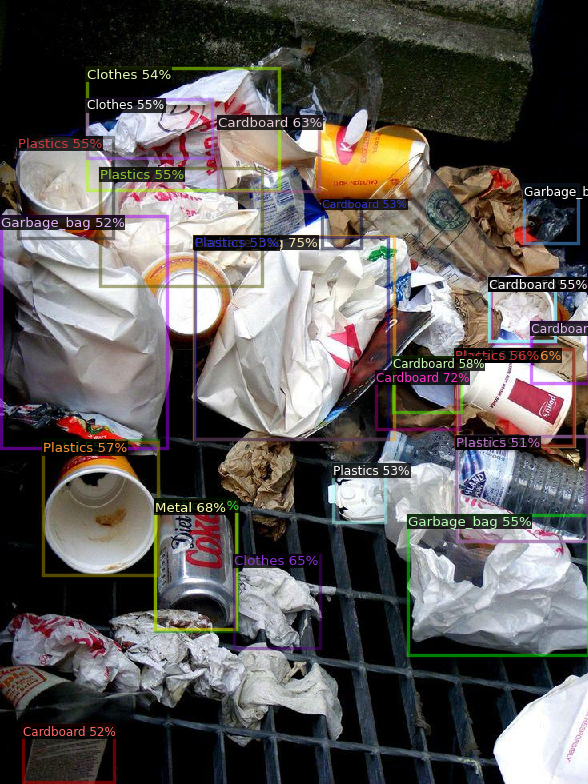

In [25]:
import time
import cv2
import random
from google.colab.patches import cv2_imshow
from detectron2.utils.visualizer import Visualizer
from detectron2.engine import DefaultPredictor

# تحميل أحسن وزن وصلناله
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_best.pth")
cfg.MODEL.RETINANET.SCORE_THRESH_TEST = 0.5
predictor = DefaultPredictor(cfg)

# (Inference Time)حساب سرعة الموديل
dataset_dicts = DatasetCatalog.get("garbage_val")
sample_img = cv2.imread(dataset_dicts[0]["file_name"])

start_time = time.time()
outputs = predictor(sample_img)
end_time = time.time()

print(f"Inference Time: {(end_time - start_time)*1000:.2f} ms per image")

# عرض نتائج عشوائية للتحليل
for d in random.sample(dataset_dicts, 1):
    img = cv2.imread(d["file_name"])
    outputs = predictor(img)
    v = Visualizer(img[:, :, ::-1], metadata=metadata, scale=0.8)
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    print(f"Showing result for: {d['file_name']}")
    cv2_imshow(out.get_image()[:, :, ::-1])

In [7]:
from google.colab import drive
import shutil

drive.mount('/content/drive')
best_weights = os.path.join(cfg.OUTPUT_DIR, "model_best.pth")
destination = "/content/drive/MyDrive/RetinaNet_Garbage_Final.pth"

if os.path.exists(best_weights):
    shutil.copy(best_weights, destination)
    print("Best model saved to Drive successfully")

Mounted at /content/drive
Best model saved to Drive successfully!


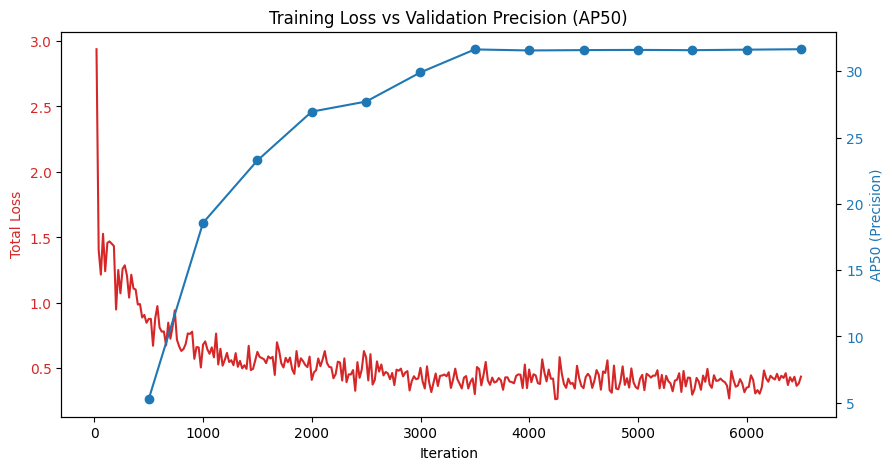

In [26]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import os

# قراءة البيانات من ملف المتركس
metrics_path = os.path.join(cfg.OUTPUT_DIR, "metrics.json")
with open(metrics_path, 'r') as f:
    metrics = [json.loads(line) for line in f]

df = pd.DataFrame(metrics)


fig, ax1 = plt.subplots(figsize=(10, 5))


ax1.set_xlabel('Iteration')
ax1.set_ylabel('Total Loss', color='tab:red')
ax1.plot(df['iteration'], df['total_loss'], color='tab:red', label='Total Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Precision (AP50)رسم الـ
ax2 = ax1.twinx()
ax2.set_ylabel('AP50 (Precision)', color='tab:blue')

eval_df = df[df['bbox/AP50'].notna()]
ax2.plot(eval_df['iteration'], eval_df['bbox/AP50'], color='tab:blue', marker='o', label='AP50')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Training Loss vs Validation Precision (AP50)')
plt.show()

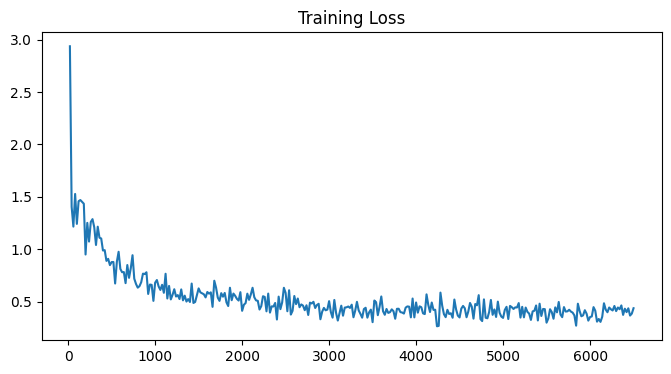

[05/12 11:16:54 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output_retinanet/model_best.pth ...
WARNING [05/12 11:16:54 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[05/12 11:16:54 d2.data.datasets.coco]: Loaded 63 images in COCO format from /content/garbage_dataset/valid/_annotations.coco.json


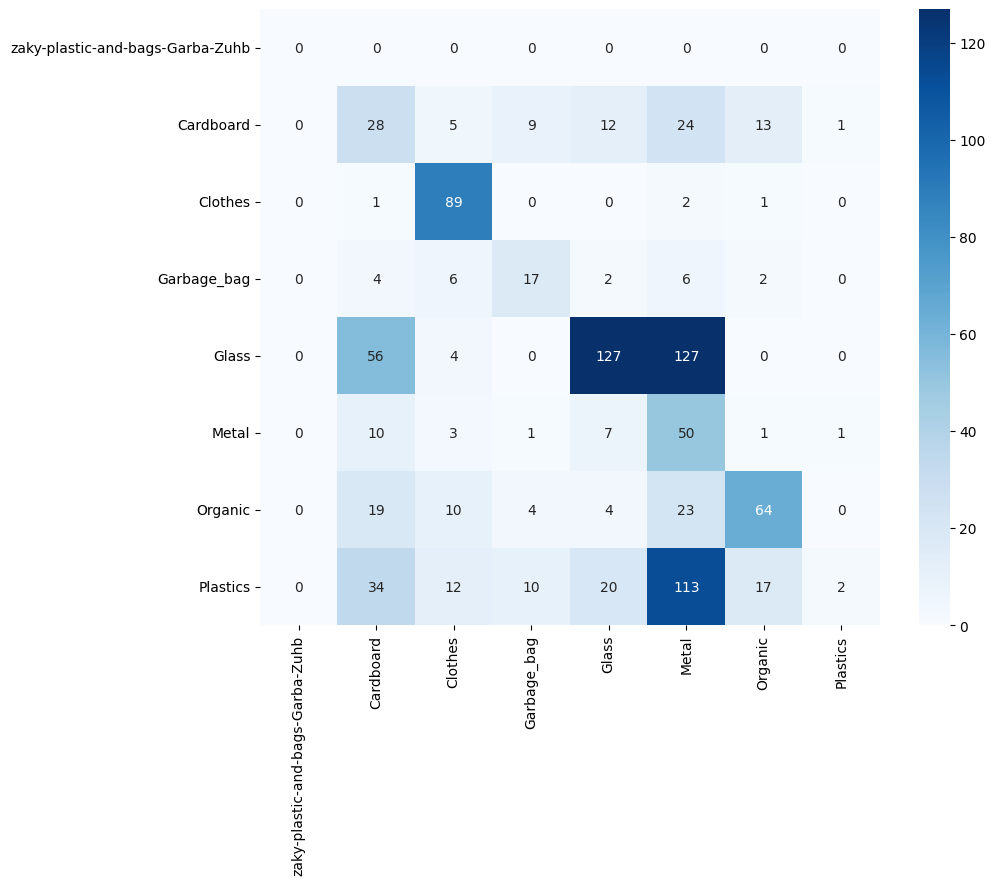

                                  precision    recall  f1-score   support

zaky-plastic-and-bags-Garba-Zuhb       0.00      0.00      0.00         0
                       Cardboard       0.18      0.30      0.23        92
                         Clothes       0.69      0.96      0.80        93
                     Garbage_bag       0.41      0.46      0.44        37
                           Glass       0.74      0.40      0.52       314
                           Metal       0.14      0.68      0.24        73
                         Organic       0.65      0.52      0.58       124
                        Plastics       0.50      0.01      0.02       208

                        accuracy                           0.40       941
                       macro avg       0.42      0.42      0.35       941
                    weighted avg       0.56      0.40      0.39       941



In [33]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import cv2
from detectron2.engine import DefaultPredictor

#  Lossرسم منحنى الـ
metrics_path = os.path.join(cfg.OUTPUT_DIR, "metrics.json")
with open(metrics_path, 'r') as f:
    metrics = [json.loads(line) for line in f]
df = pd.DataFrame(metrics)

plt.figure(figsize=(8, 4))
plt.plot(df['iteration'], df['total_loss'], label='Loss')
plt.title('Training Loss')
plt.show()

# 2.Validationعلى عينة من الـ  Confusion Matrixحساب الـ
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_best.pth")
cfg.MODEL.RETINANET.SCORE_THRESH_TEST = 0.5
predictor = DefaultPredictor(cfg)
dataset_dicts = DatasetCatalog.get("garbage_val")

y_true, y_pred = [], []
for d in dataset_dicts[:500]: # عينة من 100 صورة للسرعة
    img = cv2.imread(d["file_name"])
    outputs = predictor(img)
    gt_classes = [anno["category_id"] for anno in d["annotations"]]
    pred_instances = outputs["instances"].to("cpu")
    if len(pred_instances) > 0:
        p_class = pred_instances.pred_classes[0].item()
        for gt in gt_classes:
            y_true.append(gt)
            y_pred.append(p_class)


cm = confusion_matrix(y_true, y_pred, labels=list(range(len(metadata.thing_classes))))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=metadata.thing_classes, yticklabels=metadata.thing_classes, cmap='Blues')
plt.show()

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(metadata.thing_classes))),
    target_names=metadata.thing_classes,
    zero_division=0 # Warning عشان ميديناش  لو كلاس مظهرش خالص
))